原始AR(2)序列 ADF检验结果：
ADF统计量: -19.3357, p值: 0.0000
结论：平稳

维纳滤波器系数（前10个）：
[ 0.59715128 -0.20360755  0.02363557 -0.06059091  0.05489398  0.00590325
 -0.00102036 -0.04738855  0.06048262 -0.00675464]


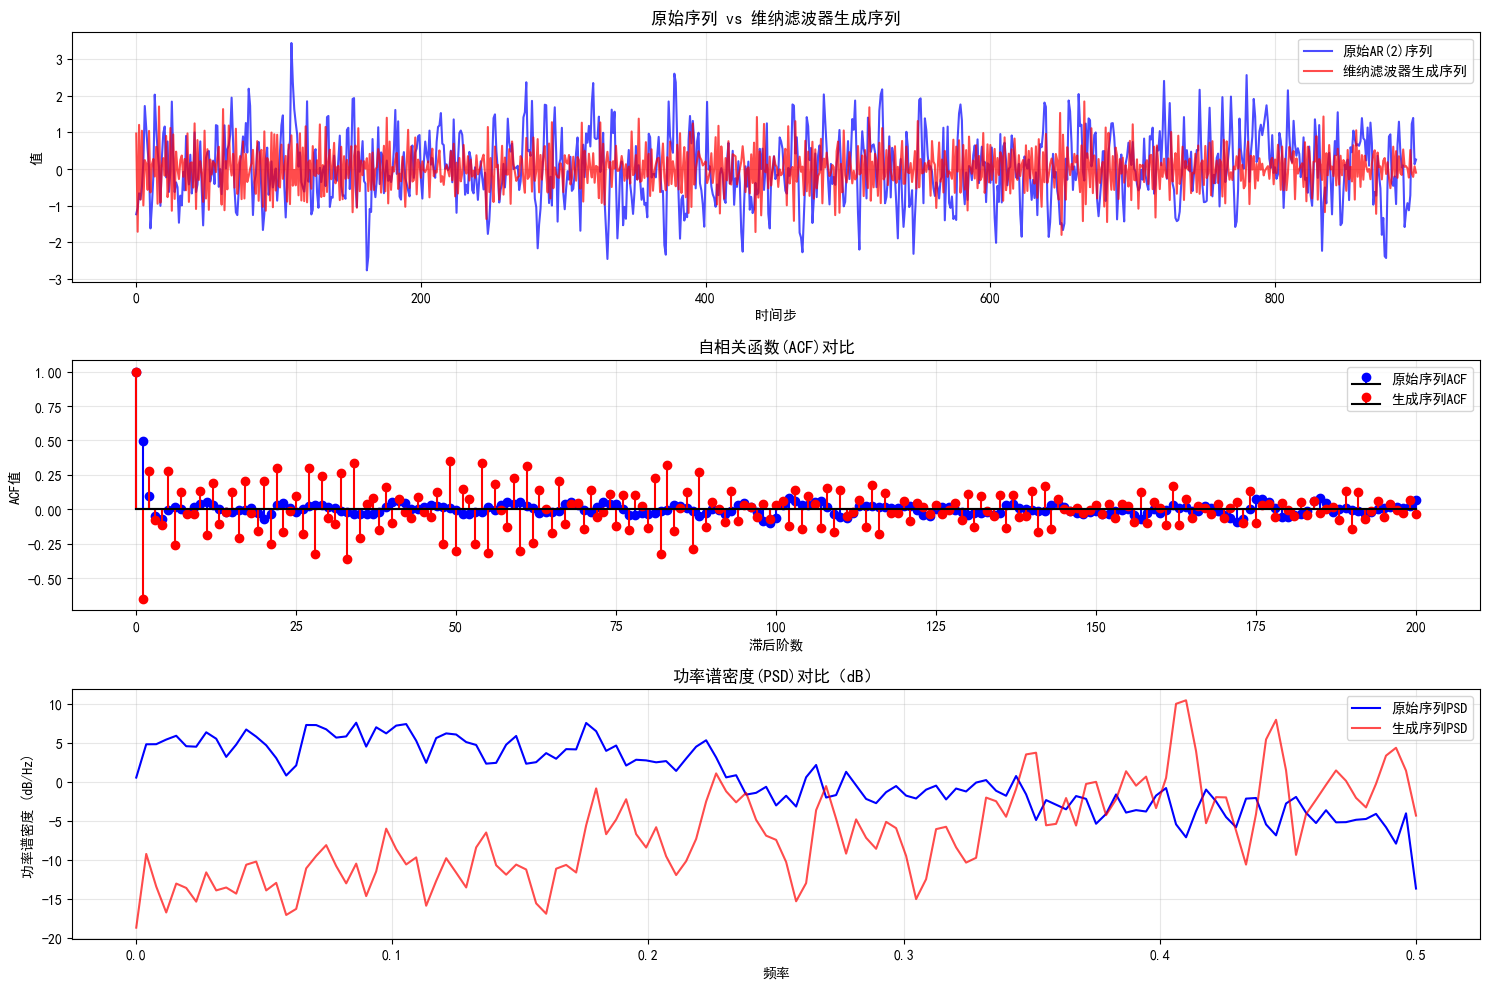

ACF均方误差：0.027368（越小越相似）
PSD（dB）均方误差：139.129031（越小越相似）


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.linalg import toeplitz
from statsmodels.tsa.stattools import acf
from statsmodels.tsa.stattools import adfuller

plt.rcParams["font.sans-serif"] = ["SimHei"]  # 显示中文
plt.rcParams["axes.unicode_minus"] = False  # 显示负号

# ---------------------- 1. 生成原始平稳时间序列（AR(2)示例，更具代表性） ----------------------
np.random.seed(42)
n_obs = 1000  # 序列长度（长序列更利于ACF估计）
# AR(2)参数：phi1=0.6, phi2=-0.2（满足平稳性条件）
phi1, phi2 = 0.6, -0.2
sigma = 0.8  # 白噪声标准差

# 生成AR(2)序列：y_t = 0.6*y_{t-1} -0.2*y_{t-2} + e_t
y = np.zeros(n_obs)
y[0] = np.random.normal(0, sigma)
y[1] = phi1 * y[0] + np.random.normal(0, sigma)
for t in range(2, n_obs):
    y[t] = phi1 * y[t - 1] + phi2 * y[t - 2] + np.random.normal(0, sigma)


# 验证原始序列平稳性
def adf_test(series, name):
    result = adfuller(series)
    print(f"{name} ADF检验结果：")
    print(f"ADF统计量: {result[0]:.4f}, p值: {result[1]:.4f}")
    print("结论：" + ("平稳" if result[1] < 0.05 else "非平稳") + "\n")


adf_test(y, "原始AR(2)序列")

# ---------------------- 2. 估计原始序列的自相关函数(ACF) ----------------------
# 计算ACF：lag_max设为滤波器阶数的2倍（保证估计精度）
filter_order = 50  # 维纳滤波器阶数（阶数越高，匹配度越好）
lag_max = filter_order * 2
acf_original = acf(y, nlags=lag_max, fft=True)  # fft=True加速计算


# ---------------------- 3. 设计维纳滤波器（基于维纳-霍夫方程） ----------------------
def design_wiener_filter(acf_vals, filter_order):
    """
    设计维纳滤波器：求解维纳-霍夫方程 R*h = r
    - R: 自相关矩阵（Toeplitz矩阵）
    - h: 滤波器系数（待求）
    - r: 自相关向量（前filter_order+1个ACF值）
    """
    # 构造自相关矩阵R（Toeplitz矩阵，尺寸：filter_order x filter_order）
    R = toeplitz(acf_vals[:filter_order])

    # 构造自相关向量r（尺寸：filter_order x 1）
    r = acf_vals[1 : filter_order + 1].reshape(-1, 1)

    # 求解维纳-霍夫方程：R*h = r → h = R^{-1}*r
    # 用伪逆避免矩阵奇异问题（更鲁棒）
    h = np.linalg.pinv(R) @ r
    return h.flatten()  # 转为一维数组


# 设计维纳滤波器
wiener_coeffs = design_wiener_filter(acf_original, filter_order)
print(f"维纳滤波器系数（前10个）：\n{wiener_coeffs[:10]}")

# ---------------------- 4. 生成白噪声激励信号 ----------------------
# 生成与原序列长度相同的白噪声（零均值、单位方差）
white_noise = np.random.normal(0, 1, size=n_obs)
# 调整白噪声方差，匹配原序列的功率水平
white_noise = white_noise * sigma

# ---------------------- 5. 白噪声激励维纳滤波器，生成新序列 ----------------------
# 用线性滤波实现：新序列 = 白噪声 * 维纳滤波器（卷积）
# 使用filtfilt避免相位失真（可选，也可用lfilter）
simulated_y = signal.filtfilt(wiener_coeffs, 1.0, white_noise)
# 去除滤波后的边缘效应（前filter_order个点）
simulated_y = simulated_y[filter_order:]
original_y_trimmed = y[filter_order:]  # 原序列同步截断

# ---------------------- 6. 验证：对比原序列和模拟序列的特征 ----------------------
# 6.1 对比自相关函数(ACF)
acf_simulated = acf(simulated_y, nlags=lag_max, fft=True)

plt.figure(figsize=(15, 10))

# 子图1：原序列 vs 模拟序列
plt.subplot(3, 1, 1)
plt.plot(original_y_trimmed, label="原始AR(2)序列", color="blue", alpha=0.7)
plt.plot(simulated_y, label="维纳滤波器生成序列", color="red", alpha=0.7)
plt.title("原始序列 vs 维纳滤波器生成序列")
plt.xlabel("时间步")
plt.ylabel("值")
plt.legend()
plt.grid(alpha=0.3)

# 子图2：ACF对比
plt.subplot(3, 1, 2)
lags = np.arange(lag_max + 1)
plt.stem(
    lags, acf_original, linefmt="b-", markerfmt="bo", basefmt="k-", label="原始序列ACF"
)
plt.stem(
    lags, acf_simulated, linefmt="r-", markerfmt="ro", basefmt="k-", label="生成序列ACF"
)
plt.title("自相关函数(ACF)对比")
plt.xlabel("滞后阶数")
plt.ylabel("ACF值")
plt.legend()
plt.grid(alpha=0.3)

# 子图3：功率谱密度(PSD)对比
plt.subplot(3, 1, 3)
# 计算功率谱密度（使用Welch方法，更平滑）
f1, Pxx1 = signal.welch(original_y_trimmed, fs=1.0, nperseg=256, scaling="density")
f2, Pxx2 = signal.welch(simulated_y, fs=1.0, nperseg=256, scaling="density")
plt.plot(f1, 10 * np.log10(Pxx1), label="原始序列PSD", color="blue")
plt.plot(f2, 10 * np.log10(Pxx2), label="生成序列PSD", color="red", alpha=0.7)
plt.title("功率谱密度(PSD)对比（dB）")
plt.xlabel("频率")
plt.ylabel("功率谱密度 (dB/Hz)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 6.2 定量验证：计算ACF和PSD的相似度（均方误差）
acf_mse = np.mean((acf_original - acf_simulated) ** 2)
psd_mse = np.mean((10 * np.log10(Pxx1) - 10 * np.log10(Pxx2)) ** 2)
print(f"ACF均方误差：{acf_mse:.6f}（越小越相似）")
print(f"PSD（dB）均方误差：{psd_mse:.6f}（越小越相似）")